<a href="https://colab.research.google.com/github/lumizel/AI_26/blob/main/03_AI%EA%B8%B0%EB%B0%98%EC%98%88%EC%B8%A1%EB%B0%8F%EB%B6%84%EC%84%9D(%EC%97%AC%EB%AF%BC%EC%97%BD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

from lightgbm import early_stopping
from tensorflow.python.keras.optimizer_v1 import adagrad, nadam


tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input,train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()


train_scaled = train_input /255.0

train_scaled,val_scaled,train_target,val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [ ]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)
print(val_scaled.shape, val_target.shape)

(60000, 28, 28) (48000,)
(10000, 28, 28) (10000,)
(12000, 28, 28) (12000,)


In [ ]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer :
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [ ]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8112 - loss: 0.5311 - val_accuracy: 0.8457 - val_loss: 0.4327
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8592 - loss: 0.3906 - val_accuracy: 0.8605 - val_loss: 0.3922
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8731 - loss: 0.3517 - val_accuracy: 0.8683 - val_loss: 0.3729
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8822 - loss: 0.3276 - val_accuracy: 0.8713 - val_loss: 0.3719
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8890 - loss: 0.3124 - val_accuracy: 0.8652 - val_loss: 0.3977
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8933 - loss: 0.2993 - val_accuracy: 0.8673 - val_loss: 0.3952
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8992 - loss: 0.2875 - val_accuracy: 0.8687 - val_loss: 0.3978
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9022 - loss: 0.2792 - 

In [ ]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'],optimizer='nadam')
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), verbose=2)

Epoch 1/20
1500/1500 - 4s - 2ms/step - accuracy: 0.8221 - loss: 0.5145 - val_accuracy: 0.8467 - val_loss: 0.4327
Epoch 2/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8621 - loss: 0.3876 - val_accuracy: 0.8561 - val_loss: 0.4010
Epoch 3/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8746 - loss: 0.3468 - val_accuracy: 0.8587 - val_loss: 0.3822
Epoch 4/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8842 - loss: 0.3199 - val_accuracy: 0.8649 - val_loss: 0.3679
Epoch 5/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8910 - loss: 0.3004 - val_accuracy: 0.8701 - val_loss: 0.3560
Epoch 6/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8968 - loss: 0.2849 - val_accuracy: 0.8719 - val_loss: 0.3497
Epoch 7/20
1500/1500 - 3s - 2ms/step - accuracy: 0.9018 - loss: 0.2706 - val_accuracy: 0.8765 - val_loss: 0.3491
Epoch 8/20
1500/1500 - 3s - 2ms/step - accuracy: 0.9055 - loss: 0.2585 - val_accuracy: 0.8754 - val_loss: 0.3538
Epoch 9/20
1500/1500 - 3s - 2ms/step - accuracy: 0.9099 - loss: 0.2472 - val_accuracy: 0.8785 - 

In [ ]:
model = model_fn(keras.layers.Dropout(0.2))
model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_29 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], optimizer='nadam')
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), verbose=2)


Epoch 1/20
1500/1500 - 7s - 4ms/step - accuracy: 0.8042 - loss: 0.5599 - val_accuracy: 0.8478 - val_loss: 0.4221
Epoch 2/20
1500/1500 - 4s - 3ms/step - accuracy: 0.8508 - loss: 0.4144 - val_accuracy: 0.8567 - val_loss: 0.3925
Epoch 3/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8616 - loss: 0.3755 - val_accuracy: 0.8687 - val_loss: 0.3586
Epoch 4/20
1500/1500 - 4s - 2ms/step - accuracy: 0.8715 - loss: 0.3531 - val_accuracy: 0.8725 - val_loss: 0.3465
Epoch 5/20
1500/1500 - 4s - 3ms/step - accuracy: 0.8773 - loss: 0.3352 - val_accuracy: 0.8724 - val_loss: 0.3426
Epoch 6/20
1500/1500 - 4s - 3ms/step - accuracy: 0.8816 - loss: 0.3218 - val_accuracy: 0.8813 - val_loss: 0.3256
Epoch 7/20
1500/1500 - 4s - 2ms/step - accuracy: 0.8854 - loss: 0.3114 - val_accuracy: 0.8789 - val_loss: 0.3274
Epoch 8/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8888 - loss: 0.3014 - val_accuracy: 0.8842 - val_loss: 0.3147
Epoch 9/20
1500/1500 - 4s - 2ms/step - accuracy: 0.8921 - loss: 0.2933 - val_accuracy: 0.8826 - 

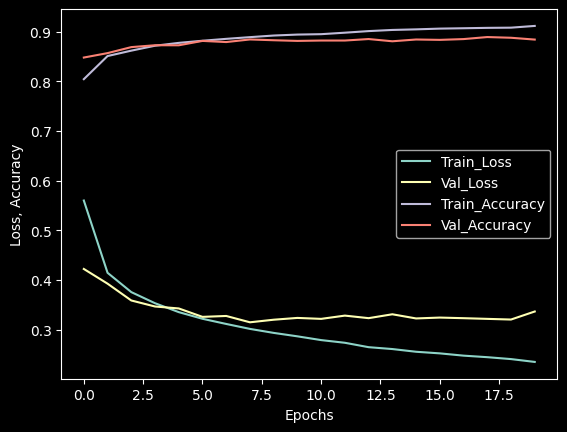

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Loss, Accuracy')
plt.legend(['Train_Loss', 'Val_Loss', 'Train_Accuracy', 'Val_Accuracy'])
plt.show()

In [ ]:
model.save('model-whole-ep10-ymy.keras')
model.save_weights('model-ep10-ymy.weights.h5') # ymy - 이니셜

In [ ]:
import glob
files = glob.glob('model*')
model = model_fn(keras.layers.Dropout(0.2))
model.load_weights('model-ep10-ymy.weights.h5')

In [ ]:
import numpy as np
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target)) # 88.6%

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step
0.8839166666666667


In [ ]:
model = keras.models.load_model('model-whole-ep10-ymy.keras')
test_scaled = test_input / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8782 - loss: 0.3666


[0.3666072487831116, 0.8781999945640564]

In [ ]:
model = model_fn(keras.layers.Dropout(0.2))
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], optimizer='nadam')
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model-ymy.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb],verbose=2)

Epoch 1/20
1500/1500 - 4s - 2ms/step - accuracy: 0.8022 - loss: 0.5651 - val_accuracy: 0.8434 - val_loss: 0.4304
Epoch 2/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8504 - loss: 0.4171 - val_accuracy: 0.8591 - val_loss: 0.3839
Epoch 3/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8614 - loss: 0.3830 - val_accuracy: 0.8681 - val_loss: 0.3602
Epoch 4/20
1500/1500 - 2s - 2ms/step - accuracy: 0.8709 - loss: 0.3567 - val_accuracy: 0.8723 - val_loss: 0.3493
Epoch 5/20
1500/1500 - 2s - 2ms/step - accuracy: 0.8765 - loss: 0.3403 - val_accuracy: 0.8774 - val_loss: 0.3398
Epoch 6/20
1500/1500 - 2s - 2ms/step - accuracy: 0.8797 - loss: 0.3264 - val_accuracy: 0.8771 - val_loss: 0.3363
Epoch 7/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8855 - loss: 0.3144 - val_accuracy: 0.8788 - val_loss: 0.3342
Epoch 8/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8862 - loss: 0.3050 - val_accuracy: 0.8802 - val_loss: 0.3287
Epoch 9/20
1500/1500 - 3s - 2ms/step - accuracy: 0.8899 - loss: 0.2959 - val_accuracy: 0.8828 - 

In [ ]:
print(early_stopping_cb.stopped_epoch)

11


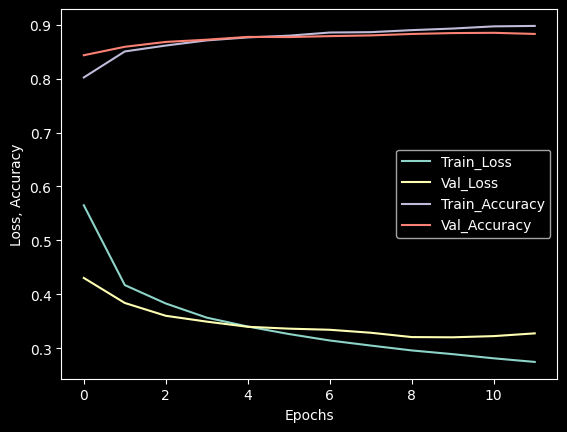

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Loss, Accuracy')
plt.legend(['Train_Loss', 'Val_Loss', 'Train_Accuracy', 'Val_Accuracy'])
plt.show()

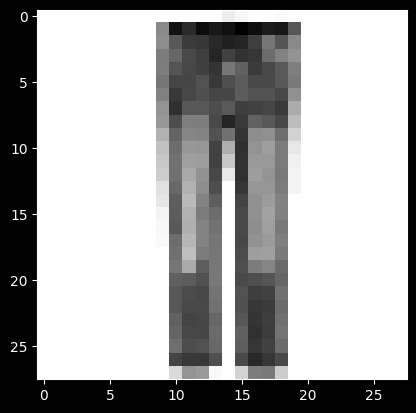

In [ ]:
plt.imshow(test_input[15], cmap='gray_r')
plt.show()